In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

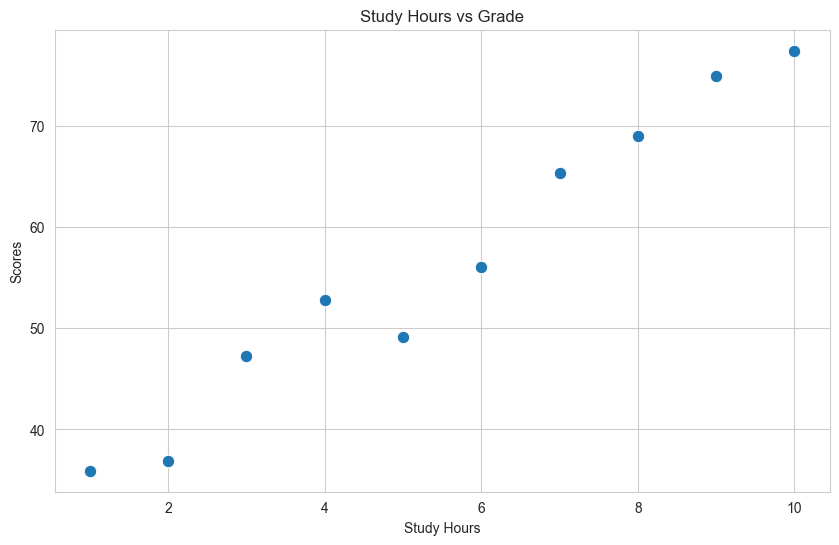

In [3]:
# rng: random number generator
rng = np.random.default_rng(42)

# generate data
max_hours = 10
study_hours = np.arange(1,max_hours+1)
#  y = 30 + 5x + noise
exam_scores = 30 + 5 * study_hours + rng.normal(0, 3, max_hours)

# plot
df = pd.DataFrame({'X': study_hours, 'y': exam_scores})
sns.scatterplot(data=df, x='X', y='y', s=80)
plt.xlabel('Study Hours')
plt.ylabel('Scores')
plt.title('Study Hours vs Grade')
plt.show()

In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177.7 kB/s eta 0:00:43
   -- ------------------------------------- 0.5/8.1 MB 177


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split

X = df[['X']] # features must be in a 2D array
y = df['y']   # single target 1D
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , random_state=42
)
print(f"X with {len(X_train)} samples (X_train) for training and {len(X_test)} for testing (X_test).")

X with 7 samples (X_train) for training and 3 for testing (X_test).


In [5]:
from sklearn.linear_model import LinearRegression
# Create model instance
model = LinearRegression()
# Train (fit) the model
model.fit(X_train, y_train)
# Print model summary
print(f"Equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f} * x")

Equation: y = 31.88 + 4.57 * x


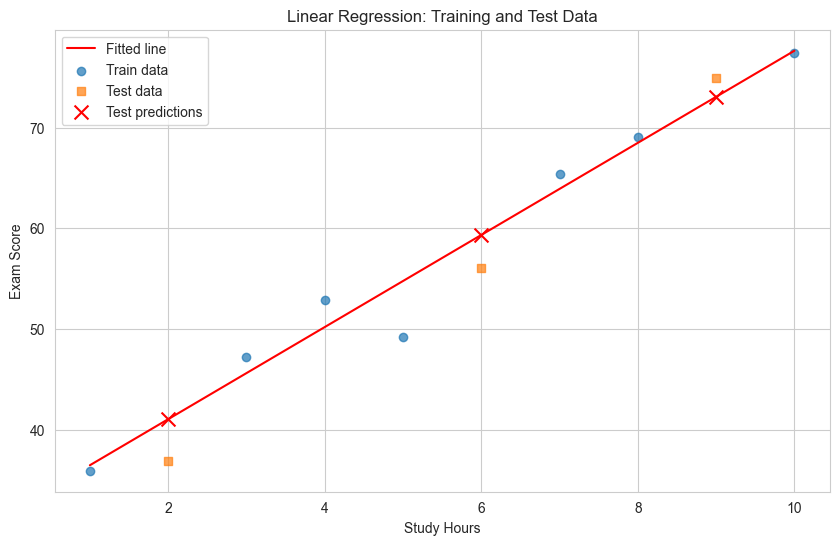

In [6]:
# Plot training and test data
df = pd.concat([
    X_train.assign(y=y_train, set="train"),
    X_test.assign(y=y_test, set="test")
], ignore_index=True)


# Fitted line
plt.plot(X, model.predict(X), 'r-', label='Fitted line')
# Predict on train and test separately
plt.scatter(X_train, y_train, label='Train data', alpha=0.7)
plt.scatter(X_test, y_test, label='Test data', marker='s', alpha=0.7)
# Optional: Mark predictions with X markers
plt.scatter(X_test, model.predict(X_test), marker='x', s=100,
            color='red', label='Test predictions', zorder=5)

# sns.lmplot(x='X', y='y', hue='sample', data=df,
#            #scatter_kws={'s': 80}  ,  # point size
#            ci=95,                    # confidence level
#            aspect=2)

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Training and Test Data')
plt.legend();

In [7]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
r2_train = r2_score(y_true=y_train, y_pred=y_train_pred)
r2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("=== Model Performance ===")
print("R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors")
print()
print(f"R²:")
print(f"\tTrain: {r2_train:.3f}")
print(f"\tTest:  {r2_test:.3f}")
print(f"The model explains {r2_test*100:.1f}% of variance in test data.")
print()
print(f"Test Set Errors:")
print(f"\tMAE:  {mae_test:.2f} points")
print(f"\tRMSE: {rmse_test:.2f} points")

=== Model Performance ===
R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors

R²:
	Train: 0.965
	Test:  0.957
The model explains 95.7% of variance in test data.

Test Set Errors:
	MAE:  3.10 points
	RMSE: 3.23 points


# Exercise 1

In [9]:
# Load diamonds dataset
diamond = sns.load_dataset('diamonds')
print(diamond.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [21]:
from sklearn.model_selection import train_test_split

diamond['cut'] = diamond['cut'].astype('category').cat.codes
diamond['color'] = diamond['color'].astype('category').cat.codes
diamond['clarity'] = diamond['clarity'].astype('category').cat.codes

# 3. Select features (X) and target variable (y)
X = diamond[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]
y = diamond['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3 , random_state=42
)
print(f"X with {len(X_train)} samples (X_train) for training and {len(X_test)} for testing (X_test).")

X with 37758 samples (X_train) for training and 16182 for testing (X_test).


In [22]:

from sklearn.linear_model import LinearRegression
# Create model instance
model = LinearRegression()
# Train (fit) the model
model.fit(X_train, y_train)
# Print model summary
print(f"Equation: y = {model.intercept_:.2f} + {model.coef_[0]:.2f} * x")

Equation: y = 9566.99 + 10697.33 * x


In [25]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
r2_train = r2_score(y_true=y_train, y_pred=y_train_pred)
r2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("=== Model Performance ===")
print("R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors")
print()
print(f"R²:")
print(f"\tTrain: {r2_train:.3f}")
print(f"\tTest:  {r2_test:.3f}")
print(f"The model explains {r2_test*100:.1f}% of variance in test data.")
print()
print(f"Test Set Errors:")
print(f"\tMAE:  {mae_test:.2f} points")
print(f"\tRMSE: {rmse_test:.2f} points")

=== Model Performance ===
R² closer to 1 = better fit | Lower MAE/RMSE = smaller errors

R²:
	Train: 0.907
	Test:  0.907
The model explains 90.7% of variance in test data.

Test Set Errors:
	MAE:  802.20 points
	RMSE: 1201.21 points


# Exercise 2

c:\Users\qstef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\qstef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\qstef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\qstef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


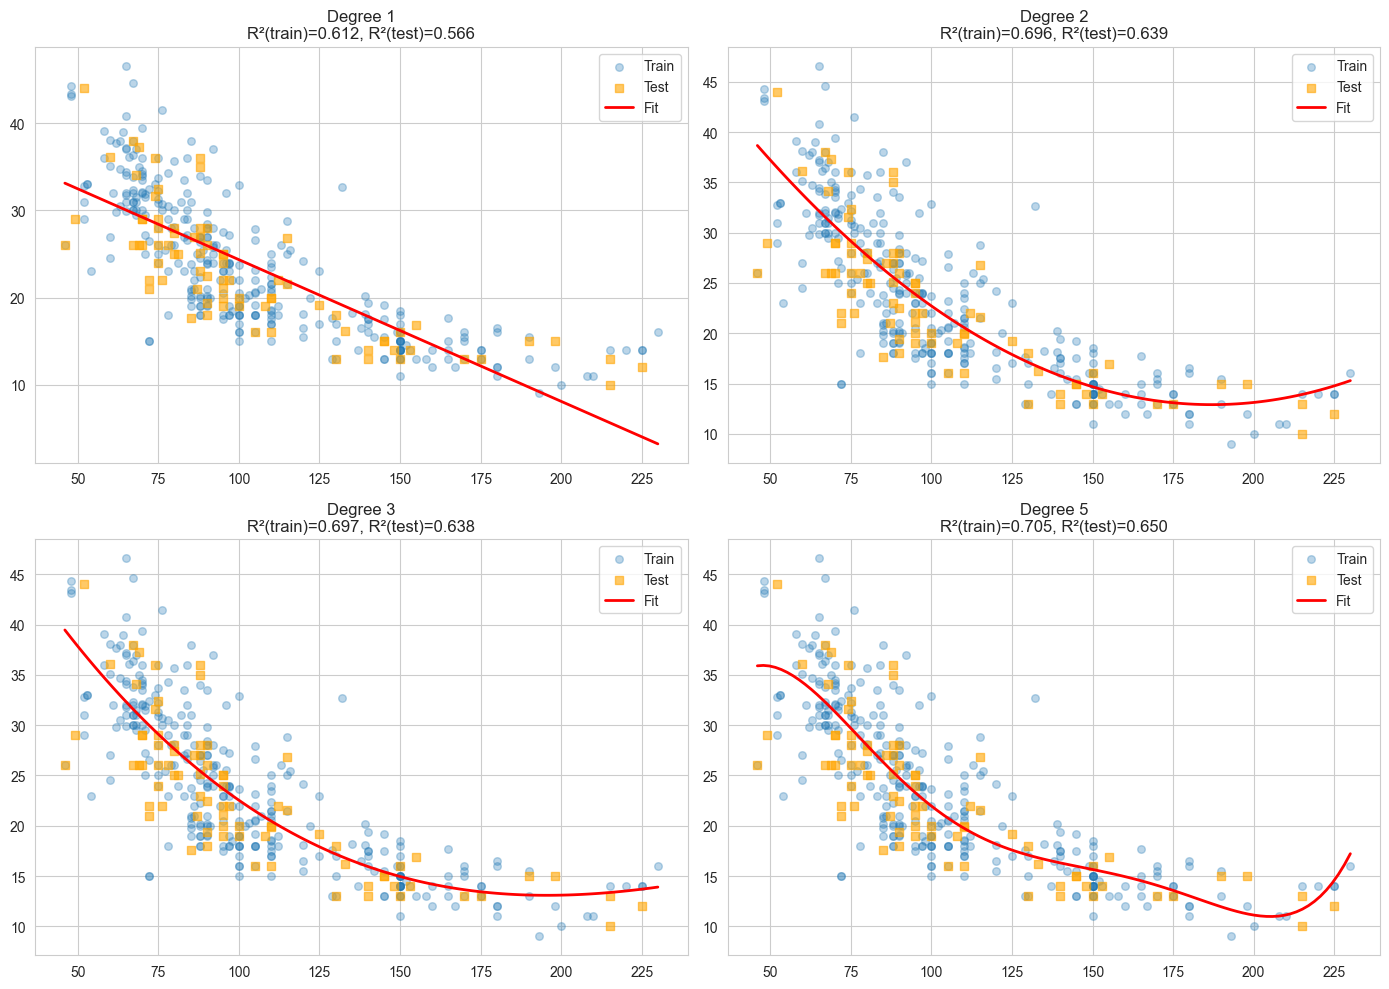

In [52]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

df_mpg = sns.load_dataset("mpg")
df_clean = df_mpg.dropna(subset=['horsepower'])

X_poly = df_clean[['horsepower']]
y_poly = df_clean['mpg']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42
)

degrees = [1, 2, 3, 5] 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

X_range = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    model_poly = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    

    model_poly.fit(X_train_p, y_train_p)
    
    r2_train = model_poly.score(X_train_p, y_train_p)
    r2_test = model_poly.score(X_test_p, y_test_p)
    y_range_pred = model_poly.predict(X_range)
    
    axes[idx].scatter(X_train_p, y_train_p, alpha=0.3, label='Train', s=30)
    axes[idx].scatter(X_test_p, y_test_p, alpha=0.6, label='Test', s=30, marker='s', color='orange')
    axes[idx].plot(X_range, y_range_pred, 'r-', linewidth=2, label='Fit')
    axes[idx].set_title(f'Degree {degree}\nR²(train)={r2_train:.3f}, R²(test)={r2_test:.3f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Exercise 3

In [57]:
import pandas as pd
import seaborn as sns
import numpy as np

iris = sns.load_dataset('iris')
X = iris.drop('species', axis=1)
y = iris['species']

def tt_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    test_count = int(len(X) * test_size)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

X_train, X_test, y_train, y_test = tt_split(X, y, test_size=0.2, random_state=42)

In [59]:
mapping = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
y_manual = iris['species'].map(mapping)

print(y_manual.unique())

[0 1 2]


In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_sklearn = le.fit_transform(iris['species'])

print(np.unique(y_sklearn))


[0 1 2]
